In [3]:
import geopandas as gpd
import fiona

In [8]:
# path and name of geopackage file
filename = 'TSRA_v2.gpkg'

In [10]:
# identify layers in geopackage
layers = fiona.listlayers(filename)
print (layers)

['shorelines_annual_1988-2025', 'rates_of_change_2021-2025', 'rates_of_change_1988-2025', 'shorelines_annual_1988-2020', 'rates_of_change_2016-2020', 'rates_of_change_1988-2020', 'shorelines_annual_1988-2015', 'rates_of_change_2011-2015', 'rates_of_change_1988-2015', 'shorelines_annual_1988-2010', 'rates_of_change_2006-2010', 'rates_of_change_1988-2010', 'shorelines_annual_1988-2005', 'rates_of_change_2001-2005', 'rates_of_change_1988-2005', 'shorelines_annual_1988-2000', 'rates_of_change_1996-2000', 'rates_of_change_1988-2000']


In [22]:
# identify epoch of interest
epoch = '1988-2020'

# identify all rates of change layers
rates = []
for layer in layers:
    if layer.split('_')[0] == 'rates':
        rates.append(layer)

# identify rates of change layer for epoch of interest
for e in rates:
    if e.split('_')[-1] == epoch:
        rate = e

# read the gpkg layer for the epoch of interest
gdf = gpd.read_file(filename, layer=rate)

In [17]:
gdf

,uid,rate_time_1988-2020,sig_time_1988-2020,se_time_1988-2020,outl_time_1988-2020,dist_1988,dist_1989,dist_1990,dist_1991,dist_1992,...,angle_std,valid_obs,valid_span,sce,nsm,max_year,min_year,certainty,id_primary,geometry
0,rnjhfm43ve,0.03,0.488,0.05,2010,-0.35,-2.97,-7.62,-2.88,-0.55,...,10,32,33,14.37,0.35,1997,1990,good,QLD04,POINT (1138005.071 -1135069.213)
1,rnjhfm4dh0,0.04,0.395,0.05,2010,-0.20,-3.00,-7.68,-2.53,0.39,...,8,32,33,14.47,0.20,1997,1990,good,QLD04,POINT (1138035.858 -1135068.795)
2,rnjhfm41z7,0.06,0.344,0.06,2010,-0.40,-2.20,-7.73,-3.06,-0.39,...,10,32,33,15.42,0.40,2002,1990,good,QLD04,POINT (1137974.542 -1135067.179)
3,rnjhfm4f63,0.06,0.218,0.05,2010,-0.09,-4.01,-6.99,-2.83,1.10,...,8,32,33,14.23,0.09,1997,1990,good,QLD04,POINT (1138066.480 -1135066.307)
4,rnjhfjpbd1,0.03,0.632,0.05,2010,2.92,-3.42,-6.03,-3.62,-1.29,...,8,32,33,17.25,-2.92,1997,1990,good,QLD04,POINT (1137601.265 -1135061.952)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20642,rnm5tz6045,-0.06,0.851,0.27,1988 1989 1990 1991 1992 1993 1994 1995 1996 1...,NaN,NaN,NaN,NaN,NaN,...,28,6,7,3.52,NaN,2017,2019,insufficient observations,None,POINT (1165544.739 -1008067.151)
20643,rnm5tz3cj5,-0.25,0.434,0.29,1988 1989 1990 1991 1992 1993 1994 1995 1996 1...,NaN,NaN,NaN,NaN,NaN,...,28,6,7,4.22,NaN,2017,2020,insufficient observations,None,POINT (1165522.357 -1008046.876)
20644,rnm5tz3f04,-0.03,0.922,0.32,1988 1989 1990 1991 1992 1993 1994 1995 1996 1...,NaN,NaN,NaN,NaN,NaN,...,28,6,7,3.78,NaN,2017,2020,insufficient observations,None,POINT (1165499.373 -1008027.287)
20645,rnm5tz3e50,0.10,0.786,0.33,1988 1989 1990 1991 1992 1993 1994 1995 1996 1...,NaN,NaN,NaN,NaN,NaN,...,28,6,7,3.79,NaN,2017,2020,insufficient observations,None,POINT (1165476.142 -1008007.891)


In [18]:
import pandas as pd
import numpy as np
from tqdm import tqdm

In [19]:
# # Get all dist_ columns
# dist_cols = [col for col in gdf.columns if col.startswith('dist_')]
# dist_cols.sort(key=lambda x: int(x.split('_')[1]))

# print(f"Found {len(dist_cols)} distance fields: {dist_cols[0]} to {dist_cols[-1]}")
# print(f"Processing {len(gdf)} features...")

# # Function to calculate R²
# def calculate_r2(y_true, y_pred):
#     ss_res = np.sum((y_true - y_pred) ** 2)
#     ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
#     if ss_tot == 0:
#         return 0
#     return (ss_res / ss_tot)

# # Function to process a single row
# def process_row(row):
#     # Get outlier years
#     outlier_string = row[f'outl_time_{epoch}']
#     if pd.notna(outlier_string):
#         outlier_years = set(str(outlier_string).replace(',', ' ').replace(';', ' ').split())
#     else:
#         outlier_years = set()
    
#     # Extract years and values, excluding outliers
#     years = []
#     values = []
    
#     for col in dist_cols:
#         year = col.split('_')[1]
#         value = row[col]
        
#         if year not in outlier_years and pd.notna(value):
#             years.append(int(year))
#             values.append(float(value))
    
#     # Need at least 4 points for cubic (degree 3)
#     if len(values) < 4:
#         return pd.Series({
#             'r2_linear': None,
#             'r2_cubic': None,
#             'is_nonlinear': None
#         })
    
#     # Convert to arrays
#     years_array = np.array(years)
#     years_since_start = years_array - years_array[0]
#     y = np.array(values)
    
#     try:
#         # Fit linear model (degree 1)
#         linear_coeffs = np.polyfit(years_since_start, y, 1)
#         y_pred_linear = np.polyval(linear_coeffs, years_since_start)
#         r2_linear = calculate_r2(y, y_pred_linear)
        
#         # Fit cubic model (degree 3)
#         cubic_coeffs = np.polyfit(years_since_start, y, 3)
#         y_pred_cubic = np.polyval(cubic_coeffs, years_since_start)
#         r2_cubic = calculate_r2(y, y_pred_cubic)
        
#         # Determine if non-linear (threshold: 0.1 difference in R²)
#         r2_diff = r2_cubic - r2_linear
#         is_nonlinear = r2_diff > 0.1
        
#         return pd.Series({
#             'r2_linear': r2_linear,
#             'r2_cubic': r2_cubic,
#             'is_nonlinear': is_nonlinear
#         })
        
#     except Exception as e:
#         return pd.Series({
#             'r2_linear': None,
#             'r2_cubic': None,
#             'is_nonlinear': None
#         })

# # Process all rows with progress bar
# print("\nProcessing features...")
# tqdm.pandas()
# results = gdf.progress_apply(process_row, axis=1)

# # Add results to geopandas dataframe
# gdf['r2_linear'] = results['r2_linear']
# gdf['r2_cubic'] = results['r2_cubic']
# gdf['is_nonlinear_0.1'] = results['is_nonlinear']

# # Summary statistics
# print(f"\n{'='*60}")
# print(f"Processing complete!")
# print(f"Successfully processed: {results['r2_linear'].notna().sum()} features")
# print(f"Skipped (insufficient data): {results['r2_linear'].isna().sum()} features")
# print(f"\nNon-linear features: {results['is_nonlinear'].sum()}")
# print(f"Linear features: {(~results['is_nonlinear']).sum()}")
# print(f"{'='*60}")

# # Show some examples
# print("\nSample results:")
# print(gdf[['r2_linear', 'r2_cubic', 'is_nonlinear_0.1']].head(10))

# # Optional: Save to file (preserves geometry)
# # gdf.to_file('output_with_linearity.gpkg', driver='GPKG')

Found 33 distance fields: dist_1988 to dist_2020
Processing 20647 features...

Processing features...


100%|██████████| 20647/20647 [00:14<00:00, 1455.14it/s]


Processing complete!
Successfully processed: 20647 features
Skipped (insufficient data): 0 features

Non-linear features: 11007
Linear features: 9640

Sample results:
   r2_linear  r2_cubic  is_nonlinear_0.1
0   0.016134  0.168305              True
1   0.024240  0.130823              True
2   0.029833  0.293247              True
3   0.050137  0.160393              True
4   0.007748  0.093985             False
5   0.053649  0.250895              True
6   0.093260  0.216650              True
7   0.000216  0.028849             False
8   0.065108  0.129591             False
9   0.000736  0.010345             False


In [29]:
# Rather than identifying when the difference between R2 is greater than a threshold, this analysis looks for time-series that see a significant improvement between linear and cubic polynomial regressions

# Calculate R² difference
gdf['r2_improvement'] = gdf['r2_cubic'] - gdf['r2_linear']

# Look at the distribution
print("R² Improvement Statistics:")
print(gdf['r2_improvement'].describe())

# Flag extreme non-linearity using percentile threshold
# Use 90th or 95th percentile to identify the most non-linear cases
threshold_90 = gdf['r2_improvement'].quantile(0.90)
threshold_95 = gdf['r2_improvement'].quantile(0.95)

gdf['extreme_nonlinear_90'] = gdf['r2_improvement'] > threshold_90
gdf['extreme_nonlinear_95'] = gdf['r2_improvement'] > threshold_95

print(f"\n90th percentile threshold: {threshold_90:.3f}")
print(f"95th percentile threshold: {threshold_95:.3f}")

print(f"\nExtreme non-linear (top 10%): {gdf['extreme_nonlinear_90'].sum()} features")
print(f"Extreme non-linear (top 5%): {gdf['extreme_nonlinear_95'].sum()} features")

# Show examples of extreme non-linearity
print("\nTop 10 most non-linear time series:")
print(gdf.nlargest(10, 'r2_improvement')[['r2_linear', 'r2_cubic', 'r2_improvement']])

R² Improvement Statistics:
count    20647.000000
mean         0.168152
std          0.174389
min          0.000006
25%          0.046564
50%          0.110542
75%          0.226582
max          0.999350
Name: r2_improvement, dtype: float64

90th percentile threshold: 0.403
95th percentile threshold: 0.541

Extreme non-linear (top 10%): 2065 features
Extreme non-linear (top 5%): 1033 features

Top 10 most non-linear time series:
       r2_linear  r2_cubic  r2_improvement
17777   0.000650  1.000000        0.999350
17857   0.000020  0.998011        0.997991
19086   0.006074  1.000000        0.993926
17771   0.008256  1.000000        0.991744
17853   0.000401  0.986206        0.985805
19402   0.015312  0.999964        0.984652
17732   0.015012  0.996250        0.981238
19087   0.019787  1.000000        0.980213
18053   0.015333  0.994390        0.979058
18013   0.016374  0.993695        0.977321


In [44]:
# gdf['r2_improvement_90']= gdf['r2_improvement']>=threshold_90
# gdf['r2_improvement_95'] = gdf['r2_improvement']>=threshold_95

print(f"Extreme non-linear (top 10%): {gdf['extreme_nonlinear_90'].sum()} features")
print(f"Total feature count: {len(gdf)}")

Extreme non-linear (top 5%): 2065 features
Total feature count: 20647


In [63]:
# Calculating the portion of non-linear points in the stable and dynamic portions

nonlin=gdf[gdf['extreme_nonlinear_90']==True]

# Extreme non-linear points in dynamic fraction
nonlinA = nonlin[nonlin[f'sig_time_{epoch}']<0.01]
nonlin_dynamic = nonlinA[nonlinA['certainty']=='good']

# Total dynamic points
dynamicA = gdf[gdf[f'sig_time_{epoch}']<0.01]
dynamic = dynamicA[dynamicA['certainty']=='good']

# Total stable points
stable = len(gdf)-len(dynamic)

# Extreme non-linear points in stable fraction
nonlinB = nonlin[nonlin[f'sig_time_{epoch}']>=0.01]
nonlin_stable = nonlinB[nonlinB['certainty']!= 'good']

print(f'For {epoch} over the whole of the Torres Strait:')
print(f'Extreme non-linear features (90th percentile) in the dynamic fraction: {len(nonlin_dynamic)}')
print(f'Extreme non-linear features (90th percentile) in the stable fraction: {len(nonlin_stable)}')
print(f'Total dynamic points: {len(dynamic)}')
print(f'Total stable points: {stable}')
print(f'Fraction of non-linear points overall: {gdf["extreme_nonlinear_90"].sum()/len(gdf)*100:.2f} %')
print(f'Fraction of non-linear points in the dynamic fraction: {len(nonlin_dynamic)/len(dynamic)*100:.2f} %')
print(f'Fraction of non-linear points in the stable fraction: {len(nonlin_stable)/stable*100:.2f} %')

For 1988-2020 over the whole of the Torres Strait:
Extreme non-linear features (90th percentile) in the dynamic fraction: 112
Extreme non-linear features (90th percentile) in the stable fraction: 1451
Total dynamic points: 4943
Total stable points: 15704
Fraction of non-linear points overall: 10.00 %
Fraction of non-linear points in the dynamic fraction: 2.27 %
Fraction of non-linear points in the stable fraction: 9.24 %


To calculate extreme non-linear coastal change points:

1. Linear and cubic-polynomial regressions were calculated for all (outlier-removed) time series of coastline change distances. (TODO - are the outliers relevant to linear regressions?)
2. R^2 for each regression type was stored and the difference calculated: R2_diff = R2 (cubic) - R2 (linear)
3. Positive values indicate that the cubic regression better described the data than a linear trend.
4. The 90th percentile of R2_diff was used to threshold and flag points with non-linear coastal change. Flagged points represent those that are significantly more likely to be non-linear than linear.

In [83]:
print(len(nonlin))
print(len(gdf))
print(len(nonlin)/len(gdf)*100)
print('-----')
print(len(nonlin_dynamic))
print(len(dynamic))
print(len(nonlin_dynamic)/len(dynamic)*100)
print('-----')
print(len(nonlin_stable))
print(stable)
print(len(nonlin_stable)/stable*100)
print('-----')
x=(len(nonlin_dynamic)+len(nonlin_stable))
print(f'Unaccounted for nonlinear points {len(nonlin)-x}')
print('-----')
print(len(nonlinA)+len(nonlinB))
print(f'Points are getting lost in the filtering on condition == or != "good": {x}')
print('-----')
print(len(gdf[gdf['certainty']=='good']))
print(len(gdf)-len(gdf[gdf['certainty']=='good']))
print(len(gdf[gdf['certainty']!='good']))
print(len(gdf)-(len(gdf[gdf['certainty']=='good']) + len(gdf[gdf['certainty']!='good'])))
print('The remainder might be those points that dont fit into nonlin_dynamic and nonlin_stable filtering')

2065
20647
10.00145299559258
-----
112
4943
2.265830467327534
-----
1451
15704
9.2396841569027
-----
Unaccounted for nonlinear points 502
-----
2065
Points are getting lost in the filtering on condition == or != "good": 1563
-----
15784
4863
4863
0
The remainder might be those points that dont fit into nonlin_dynamic and nonlin_stable filtering


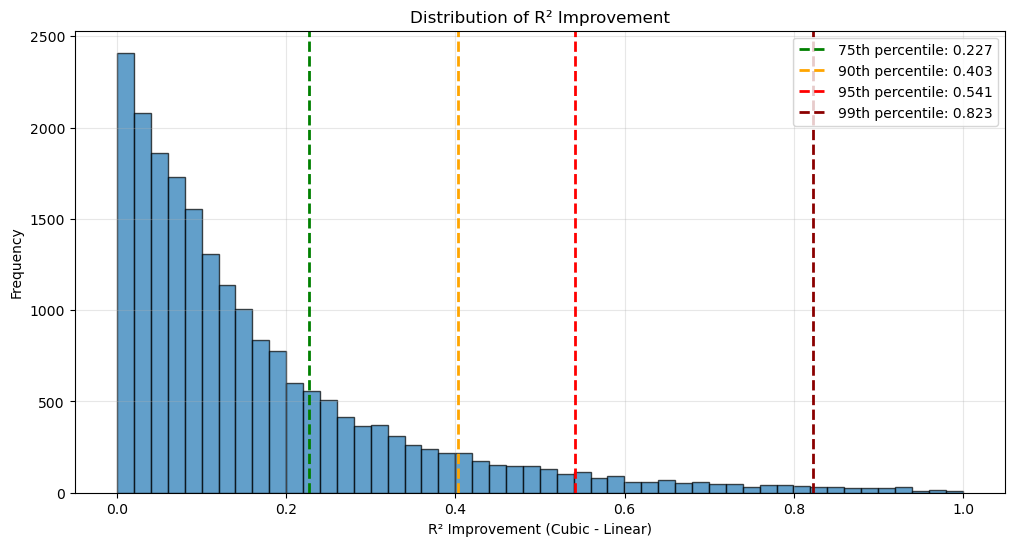

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(gdf['r2_improvement'].dropna(), bins=50, edgecolor='black', alpha=0.7)

# Add vertical lines for quantiles
quantiles = [0.75, 0.90, 0.95, 0.99]
colors = ['green', 'orange', 'red', 'darkred']

for q, color in zip(quantiles, colors):
    q_value = gdf['r2_improvement'].quantile(q)
    plt.axvline(q_value, color=color, linestyle='--', linewidth=2, 
                label=f'{int(q*100)}th percentile: {q_value:.3f}')

plt.xlabel('R² Improvement (Cubic - Linear)')
plt.ylabel('Frequency')
plt.title('Distribution of R² Improvement')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()